# 01 · Exploratory data analysis (Task 1: characteristics)

> This notebook runs the same steps as `src/eda.py`, one cell at a time, with explanations and intermediate results. Both use the shared code in `src/salary/`, so the numbers are identical.

**Question:** what is in the data, and what does it tell us about how to find salary payments?

Contents:
1. Structure and data quality
2. Who is in the data: persons, banks, accounts, coverage
3. Amounts: credits vs. debits
4. Salary: how many, how large, how stable
5. Timing: when does money arrive?
6. Text: what does the remittance information say?
7. Other income: pensions, CSN, benefits
8. Summary of findings and what they mean for the model

The numbers and figures used in the slides are saved to `reports/` at the end.
Run order: `01_eda` → `02_classifier` → `03_validation`.

In [ ]:
%matplotlib inline
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from salary.data import load_transactions
from salary.style import COLORS, save, setup

setup()
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 160)
REPORTS = ROOT / "reports"
FIG = REPORTS / "figures"
FIG.mkdir(parents=True, exist_ok=True)


def rounded(df, n=2):
    # Round numeric columns only (dates stay as they are).
    return df.round({c: n for c in df.select_dtypes("number").columns})

## 1. Structure and data quality

The raw file is a list of persons. Each person has a bank, one or two accounts, and a list of
transactions.

In [2]:
raw = json.loads((ROOT / "data" / "transactions.json").read_text(encoding="utf-8"))
first = raw[0]
print(f"{len(raw)} persons. Keys of one person: {list(first)}")
print(json.dumps({k: v for k, v in first.items() if k != "transactions"}, indent=1, ensure_ascii=False))
print("One transaction:")
print(json.dumps(first["transactions"][0], indent=1, ensure_ascii=False))

100 persons. Keys of one person: ['person_id', 'bank', 'accounts', 'transactions']
{
 "person_id": "P001",
 "bank": {
  "logo": "https://enablebanking.com/brands/SE/Swedbank/",
  "name": "Swedbank",
  "country": "SE"
 },
 "accounts": [
  {
   "uid": "SE85100-00-85100-0000-000001",
   "name": "Amina Karlsson",
   "product": "Privatkonto",
   "currency": "SEK"
  },
  {
   "uid": "SE85100-01-85100-0001-000001",
   "name": "Amina Karlsson",
   "product": "Sparkonto",
   "currency": "SEK"
  }
 ]
}
One transaction:
{
 "bank_account_id": "SE85100-00-85100-0000-000001",
 "transaction_date": "2025-01-02",
 "transaction_amount": {
  "amount": 606.3,
  "currency": "SEK"
 },
 "credit_debit_indicator": "DBIT",
 "remittance_information": [
  "lidl"
 ],
 "is_salary": false
}


`load_transactions` (in `src/salary/data.py`) flattens this into one row per transaction and
keeps the account product (Privatkonto/Sparkonto) next to each transaction.

In [3]:
txns = load_transactions()
txns.head()

,person_id,bank,n_accounts,account_id,product,date,amount,currency,is_credit,text,is_salary,txn_id
0,P001,Swedbank,2,SE85100-00-85100-0000-000001,Privatkonto,2025-01-02,606.30,SEK,False,lidl,False,0
1,P001,Swedbank,2,SE85100-00-85100-0000-000001,Privatkonto,2025-01-02,140.00,SEK,False,A-kassan medlemsavgift,False,1
2,P001,Swedbank,2,SE85100-00-85100-0000-000001,Privatkonto,2025-01-04,119.00,SEK,False,SPOTIFY,False,2
3,P001,Swedbank,2,SE85100-00-85100-0000-000001,Privatkonto,2025-01-05,80.91,SEK,False,PIZZERIA ROMA,False,3
4,P001,Swedbank,2,SE85100-00-85100-0000-000001,Privatkonto,2025-01-05,299.00,SEK,False,TRE ABONNEMANG ID:20250105-195,False,4


In [4]:
names = pd.Series([p["accounts"][0]["name"] for p in raw])
quality = pd.Series({
    "transactions": len(txns),
    "persons (person_id)": txns.person_id.nunique(),
    "distinct account-holder names": names.nunique(),
    "names shared by 2+ persons": int((names.value_counts() > 1).sum()),
    "date range": f"{txns.date.min():%Y-%m-%d} to {txns.date.max():%Y-%m-%d}",
    "currencies": ", ".join(txns.currency.unique()),
    "amounts <= 0": int((txns.amount <= 0).sum()),
    "empty remittance text": int((txns.text.str.strip() == "").sum()),
    "duplicate rows (person, account, date, amount, text)": int(
        txns.duplicated(["person_id", "account_id", "date", "amount", "text"]).sum()),
    "transactions labelled salary": int(txns.is_salary.sum()),
}, name="value")
quality.to_frame()

,value
transactions,30301
persons (person_id),100
distinct account-holder names,87
names shared by 2+ persons,12
date range,2025-01-01 to 2025-12-31
currencies,SEK
amounts <= 0,0
empty remittance text,966
"duplicate rows (person, account, date, amount, text)",0
transactions labelled salary,876


- Everything is in SEK and all amounts are positive; the direction is in `credit_debit_indicator`.
- Names are not unique: several persons share a name. We use `person_id`, as the brief says.
- Some texts are empty. That will matter (section 6).

## 2. Who is in the data

In [5]:
direction = txns.is_credit.map({True: "credit", False: "debit"})
pd.concat({
    "transactions": pd.crosstab(direction, txns["product"], margins=True),
    "of which salary": pd.crosstab(direction, txns["product"], values=txns.is_salary,
                                   aggfunc="sum", margins=True).fillna(0).astype(int),
}, axis=1)

transactions                  of which salary               
product    Privatkonto Sparkonto    All     Privatkonto Sparkonto  All
is_credit                                                             
credit            2003        90   2093             876         0  876
debit            28082       126  28208               0         0    0
All              30085       216  30301             876         0  876

**Finding 1:** 93% of transactions are debits, and no debit is ever salary. Every salary is a
credit to the main account (Privatkonto). That leaves **2,093 credits** as candidates.

In [6]:
persons = txns.groupby("person_id").agg(
    bank=("bank", "first"), accounts=("n_accounts", "first"),
    transactions=("txn_id", "size"), start=("date", "min"), end=("date", "max"),
    months=("date", lambda d: d.dt.to_period("M").nunique()),
    salaries=("is_salary", "sum"))
persons["has_salary"] = persons.salaries > 0

display(pd.crosstab(persons.bank, persons.has_salary.map({True: "salary", False: "no salary"}), margins=True))
persons[["transactions", "months", "accounts"]].describe().round(1)

has_salary,no salary,salary,All
bank,,,
Handelsbanken,5,17,22
Nordea,8,13,21
SEB,9,16,25
Swedbank,9,23,32
All,31,69,100


,transactions,months,accounts
count,100.0,100.0,100.0
mean,303.0,11.2,1.3
std,74.8,2.0,0.4
min,104.0,5.0,1.0
25%,258.0,12.0,1.0
50%,304.5,12.0,1.0
75%,368.0,12.0,2.0
max,396.0,12.0,2.0


start after January: 11 | end before December: 6 | fewer than 12 months: 17


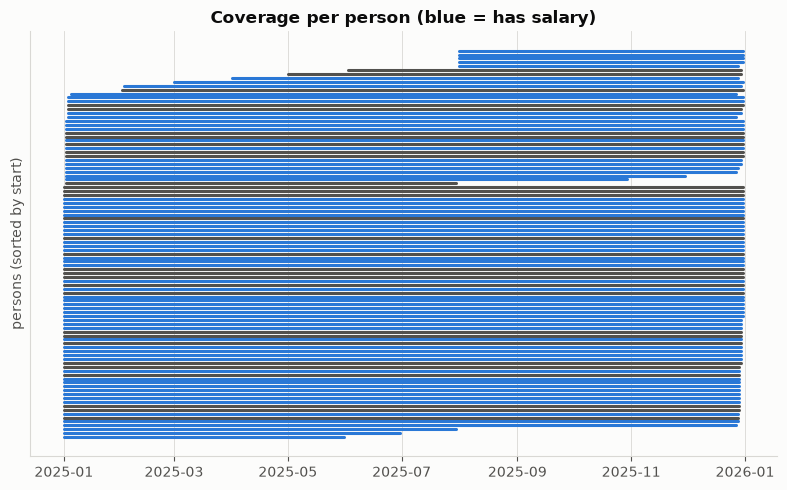

In [7]:
# Coverage: when does each person's history start and end?
p = persons.sort_values(["start", "end"]).reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
for i, r in p.iterrows():
    ax.plot([r.start, r.end], [i, i], lw=2.2, solid_capstyle="round",
            color=COLORS["blue"] if r.has_salary else COLORS["muted"])
ax.set(yticks=[], ylabel="persons (sorted by start)", title="Coverage per person (blue = has salary)")
ax.grid(axis="y", visible=False)
save(fig, FIG / "eda_coverage.png")

print("start after January:", int((persons.start > "2025-01-31").sum()),
      "| end before December:", int((persons.end < "2025-12-01").sum()),
      "| fewer than 12 months:", int((persons.months < 12).sum()))

**Finding 2:** coverage varies: 11 persons start after January, 6 end before December. Any
"per month" income number must divide by the months the person is actually observed, not by 12.

## 3. Amounts: credits vs. debits

To analyse credits we give each one a rough *income type* from text keywords (the keyword groups
are defined in `src/salary/features.py` and explained in notebook 02). The type is only for
exploration; the model never sees it.

In [8]:
from salary.features import build_features, payday_25

X = build_features(txns)   # credits only, with text keyword flags and pattern features


def income_type(X):
    t = pd.Series("Swish / private", index=X.index)
    t[X.kw_own_transfer == 1] = "Own transfer"
    t[X.kw_student_aid == 1] = "CSN (student aid)"
    t[X.kw_unemployment == 1] = "A-kassa"
    t[X.kw_pension == 1] = "Pension"
    t[(X.kw_tax_refund == 1) | (X.kw_insurance == 1)] = "Tax refund / insurance"
    t[X.kw_social_insurance == 1] = "Försäkringskassan"
    t[X.is_salary] = "Salary"          # the label wins
    return t


X["income_type"] = income_type(X)
X["on_payday25"] = X["date"] == payday_25(X["date"])
sal = X[X.is_salary]
TYPE_ORDER = ["Salary", "CSN (student aid)", "A-kassa", "Försäkringskassan", "Pension",
              "Tax refund / insurance", "Own transfer", "Swish / private"]

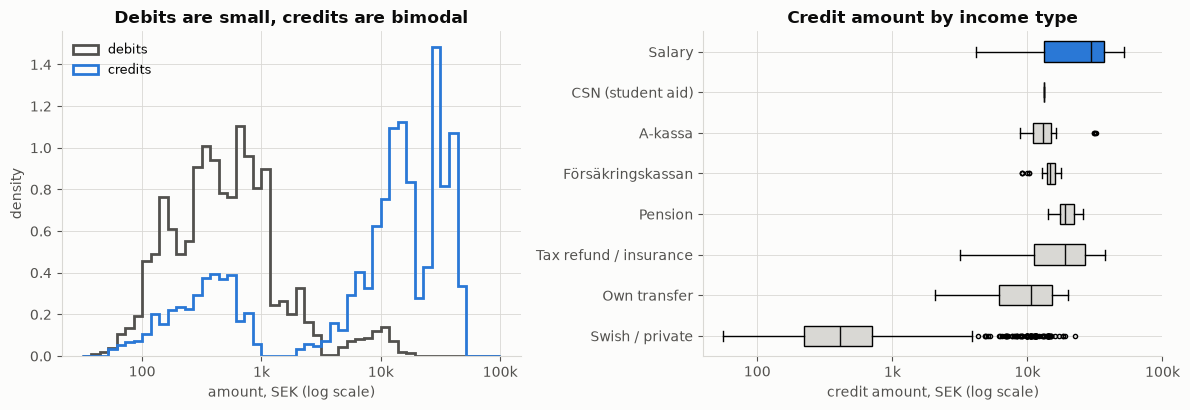

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
bins = np.linspace(1.5, 5, 50)
for is_credit, color, label in [(False, COLORS["muted"], "debits"), (True, COLORS["blue"], "credits")]:
    axes[0].hist(np.log10(txns.loc[txns.is_credit == is_credit, "amount"]), bins=bins,
                 histtype="step", lw=2, color=color, label=label, density=True)
axes[0].set(xlabel="amount, SEK (log scale)", ylabel="density", title="Debits are small, credits are bimodal")
axes[0].set_xticks([2, 3, 4, 5], ["100", "1k", "10k", "100k"])
axes[0].legend(frameon=False)

data = [np.log10(X.loc[X.income_type == t, "amount"]) for t in TYPE_ORDER]
bp = axes[1].boxplot(data, orientation="horizontal", tick_labels=TYPE_ORDER, widths=0.5, patch_artist=True,
                     medianprops={"color": COLORS["ink"]}, flierprops={"markersize": 3})
for patch, t in zip(bp["boxes"], TYPE_ORDER):
    patch.set_facecolor(COLORS["blue"] if t == "Salary" else "#d9d8d4")
axes[1].invert_yaxis()
axes[1].set_xticks([2, 3, 4, 5], ["100", "1k", "10k", "100k"])
axes[1].set(xlabel="credit amount, SEK (log scale)", title="Credit amount by income type")
save(fig, FIG / "eda_amounts.png")

In [10]:
X.groupby("income_type").amount.describe(percentiles=[0.1, 0.5, 0.9]).loc[TYPE_ORDER].round(0)

,count,mean,std,min,10%,50%,90%,max
income_type,,,,,,,,
Salary,876.0,26404.0,12893.0,4148.0,7833.0,29475.0,42996.0,51586.0
CSN (student aid),72.0,13156.0,0.0,13156.0,13156.0,13156.0,13156.0,13156.0
A-kassa,44.0,14244.0,5975.0,8818.0,9599.0,13075.0,16136.0,32425.0
Försäkringskassan,50.0,14550.0,2139.0,9106.0,10298.0,14743.0,16678.0,17687.0
Pension,138.0,19704.0,3397.0,14291.0,15867.0,18904.0,25559.0,25938.0
Tax refund / insurance,36.0,18800.0,9783.0,3171.0,5767.0,18917.0,30723.0,37266.0
Own transfer,211.0,10680.0,5075.0,2054.0,3855.0,10578.0,17648.0,19820.0
Swish / private,666.0,2192.0,4184.0,56.0,129.0,409.0,10470.0,22403.0


**Finding 3:** salary is the largest regular credit (median ≈ 29k SEK), but its range overlaps
with pensions, CSN, a-kassa, Försäkringskassan and own transfers (all 10–20k). **Amount alone
cannot identify salary.** Swish and private payments are small (median ≈ 400 SEK).

## 4. Salary: how many, how large, how stable

In [11]:
sal_m = sal.assign(month=sal.date.dt.to_period("M"))
earners = sal_m.groupby("person_id").agg(
    payments=("amount", "size"), months_paid=("month", "nunique"),
    median_payment=("amount", "median"),
    cv=("amount", lambda a: a.std() / a.mean()))
earners["months_observed"] = persons.loc[earners.index, "months"]
earners["monthly_salary"] = sal_m.groupby("person_id").amount.sum() / earners.months_observed
earners["per_month"] = earners.payments / earners.months_paid

print(f"{len(sal)} salary payments, {len(earners)} of {len(persons)} persons have salary "
      f"({len(persons) - len(earners)} have none)")
earners[["payments", "median_payment", "monthly_salary", "cv", "per_month"]].describe().round(2)

876 salary payments, 69 of 100 persons have salary (31 have none)


,payments,median_payment,monthly_salary,cv,per_month
count,69.00,69.00,69.00,69.00,69.00
mean,12.70,28639.72,30562.10,0.17,1.18
std,4.06,12519.55,11720.95,0.15,0.27
min,4.00,5450.46,4344.05,0.01,1.00
25%,12.00,14990.56,23082.58,0.01,1.00
50%,13.00,30010.15,31370.18,0.17,1.08
75%,13.00,38921.94,39409.86,0.24,1.20
max,24.00,50711.38,52623.72,0.55,2.00


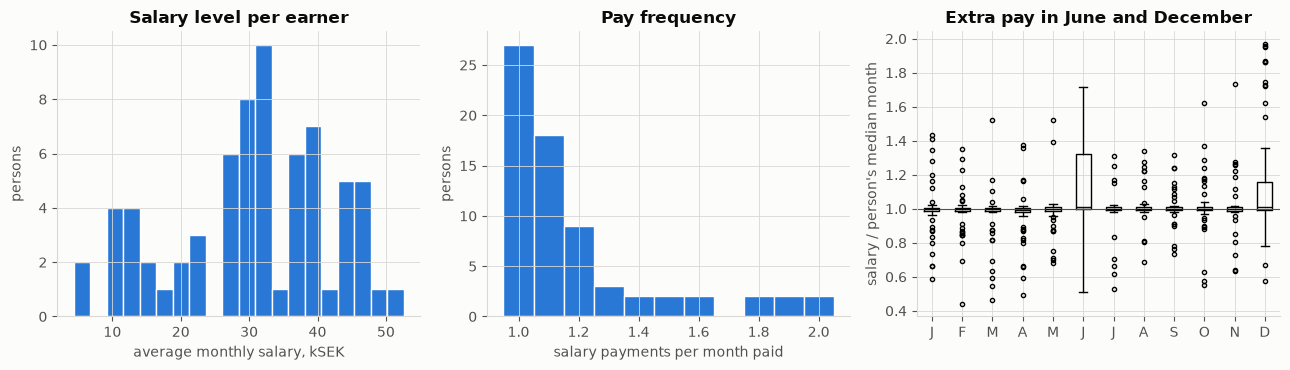

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].hist(earners.monthly_salary / 1000, bins=20, color=COLORS["blue"], edgecolor="white")
axes[0].set(xlabel="average monthly salary, kSEK", ylabel="persons", title="Salary level per earner")

axes[1].hist(earners.per_month, bins=np.arange(0.95, 2.1, 0.1), color=COLORS["blue"], edgecolor="white")
axes[1].set(xlabel="salary payments per month paid", ylabel="persons", title="Pay frequency")

# Month-by-month: each person's monthly salary relative to their own typical month
pm = sal_m.groupby(["person_id", "month"]).amount.sum().rename("amount").reset_index()
pm["ratio"] = pm.amount / pm.groupby("person_id").amount.transform("median")
pm["m"] = pm.month.dt.month
axes[2].boxplot([pm.loc[pm.m == m, "ratio"] for m in range(1, 13)], tick_labels=list("JFMAMJJASOND"),
                widths=0.5, flierprops={"markersize": 3}, medianprops={"color": COLORS["ink"]})
axes[2].axhline(1, color=COLORS["muted"], lw=0.8)
axes[2].set(ylabel="salary / person's median month", title="Extra pay in June and December")
save(fig, FIG / "eda_salary.png")

In [13]:
# What are the extra payments?
extra = sal[sal.kw_bonus_holiday == 1]
extra.groupby(extra.date.dt.month_name()).agg(n=("amount", "size"), median=("amount", "median"),
                                              examples=("text", lambda t: list(t)[:3]))

,n,median,examples
date,,,
December,10,29624.195,"[BONUS, bonus vega data ab 251219, Bonus Sigma Media AB 2025-12]"
June,12,11507.735,"[Semesterersätt, SEMESTERERS, Semesterersättning Solna Transport G..."


**Finding 4:** the 69 earners get a median ≈ 31k SEK per month. 8 of them are paid **twice a
month**. The regular payment is stable within a person, but there is extra pay in **June
(holiday pay, semesterersättning)** and **December (bonus)**, which the label counts as salary.

## 5. Timing: when does money arrive?

Swedish convention: salary is paid on the **25th, or on the last bank day before it** if the
25th is a weekend or holiday (`payday_25` in `src/salary/features.py`).

In [14]:
months = pd.Series(pd.date_range("2025-01-01", periods=12, freq="MS"))
pd.DataFrame({"payday": payday_25(months).strftime("%d %b (%a)")}, index=months.dt.strftime("%b")).T

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
payday,24 Jan (Fri),25 Feb (Tue),25 Mar (Tue),25 Apr (Fri),23 May (Fri),25 Jun (Wed),25 Jul (Fri),25 Aug (Mon),25 Sep (Thu),24 Oct (Fri),25 Nov (Tue),23 Dec (Tue)


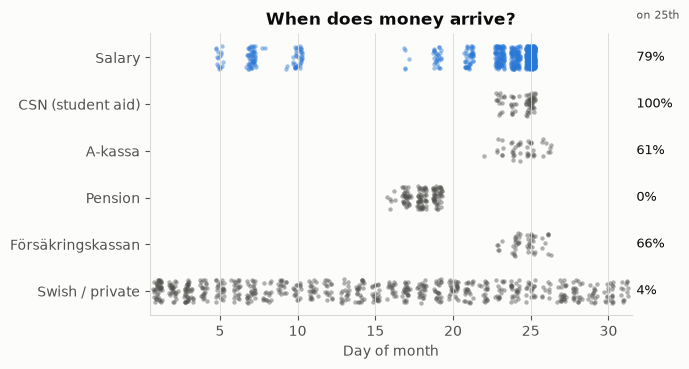

In [15]:
order = ["Salary", "CSN (student aid)", "A-kassa", "Pension", "Försäkringskassan", "Swish / private"]
fig, ax = plt.subplots(figsize=(7, 3.8))
rng = np.random.default_rng(0)
for i, t in enumerate(order):
    d = X[X.income_type == t]
    ax.scatter(d.date.dt.day + rng.uniform(-0.3, 0.3, len(d)), i + rng.uniform(-0.25, 0.25, len(d)),
               s=10, alpha=0.45, lw=0, color=COLORS["blue"] if t == "Salary" else COLORS["muted"])
    ax.text(31.8, i, f"{d.on_payday25.mean():.0%}", va="center", color=COLORS["ink"], fontsize=9)
ax.text(31.8, -0.9, "on 25th", va="center", color=COLORS["muted"], fontsize=8)
ax.set_yticks(range(len(order)), order)
ax.invert_yaxis()
ax.set(xlabel="Day of month", xlim=(0.5, 31.5), title="When does money arrive?")
ax.grid(axis="y", visible=False)
save(fig, FIG / "payday.png")

In [16]:
X.groupby("income_type").agg(
    credits=("amount", "size"), persons=("person_id", "nunique"),
    median_day=("date", lambda d: d.dt.day.median()),
    share_on_payday25=("on_payday25", "mean"),
    weekend_share=("date", lambda d: (d.dt.dayofweek >= 5).mean()),
).loc[TYPE_ORDER].round(2)

,credits,persons,median_day,share_on_payday25,weekend_share
income_type,,,,,
Salary,876,69,25.0,0.79,0.00
CSN (student aid),72,8,25.0,1.00,0.00
A-kassa,44,4,24.0,0.61,0.00
Försäkringskassan,50,5,25.0,0.66,0.00
Pension,138,12,18.0,0.00,0.00
Tax refund / insurance,36,36,10.0,0.00,0.19
Own transfer,211,27,17.0,0.02,0.29
Swish / private,666,100,15.0,0.04,0.27


In [17]:
# The twice-a-month earners: which days?
twice = earners[earners.per_month > 1.5].index
sal[sal.person_id.isin(twice)].groupby("person_id").date.agg(
    lambda d: sorted(d.dt.day.value_counts().head(2).index.tolist())).rename("main pay days").to_frame().T

person_id,P005,P022,P033,P067,P073,P076,P077,P087
main pay days,"[7, 21]","[7, 21]","[10, 25]","[7, 21]","[7, 21]","[7, 21]","[7, 21]","[10, 25]"


**Finding 5:** 79% of salaries arrive exactly on the 25th payday. The twice-a-month earners are
paid on the 7th + 21st or the 10th + 25th. Salary never arrives on a weekend.

But the rhythm is **not unique to salary**:
- **CSN** arrives on the 25th payday in **100%** of cases.
- **A-kassa and Försäkringskassan** arrive around the 25th too.
- **Pensions** arrive on the 16th–19th.

**Timing separates salary from Swish and pensions, but not from CSN and benefits.**

## 6. Text: what does the remittance information say?

,salaries,examples,share
slice,,,
salary keyword,558,"[LÖN 2025-02-25, LÖN 2025-03-25, LÖN 2025-04-25, lön 2025-05-23]",0.637
employer name,181,"[Vega Bygg HB, Utbetalning Falk Montage HB ., SOLNA TRANSPORT GROU...",0.207
empty text,84,[],0.096
other text,42,"[Semesterersätt, SEMESTERERS, Väst Fastigheter Sverige 2025-01, Vä...",0.048
corrupted text,11,"[L N 2025-01-24, L N, V ST ST DSERVICE HB jan, L N jul]",0.013


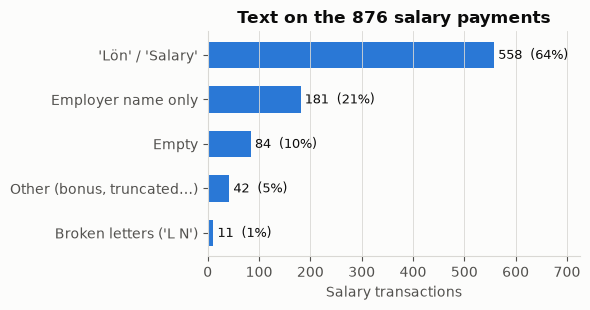

In [18]:
from salary.evaluate import text_slice

X["slice"] = text_slice(X)
labels = {"salary keyword": "'Lön' / 'Salary'", "employer name": "Employer name only",
          "empty text": "Empty", "other text": "Other (bonus, truncated…)",
          "corrupted text": "Broken letters ('L N')"}
evidence = X[X.is_salary].groupby("slice").agg(
    salaries=("amount", "size"), examples=("text", lambda t: list(t.drop_duplicates())[:4]))
evidence["share"] = (evidence.salaries / evidence.salaries.sum()).round(3)
evidence = evidence.sort_values("salaries", ascending=False)
display(evidence)

counts = evidence.salaries.rename(labels)[::-1]
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.barh(counts.index, counts.values, color=COLORS["blue"], height=0.6)
for i, v in enumerate(counts.values):
    ax.text(v + 8, i, f"{v}  ({v / counts.sum():.0%})", va="center", fontsize=9, color=COLORS["ink"])
ax.set(xlim=(0, counts.max() * 1.3), xlabel="Salary transactions", title=f"Text on the {len(sal)} salary payments")
ax.grid(axis="y", visible=False)
save(fig, FIG / "salary_text.png")

36% of salaries do **not** say "lön" or "salary". Now the other direction: credits that **do**
say "lön" but are **not** salary.

In [19]:
decoys = X[(X.kw_salary == 1) & ~X.is_salary]
print(f"{len(decoys)} non-salary credits mention 'lön', spread over {decoys.person_id.nunique()} persons")
decoys.groupby("text_key").agg(n=("amount", "size"), median_amount=("amount", "median"),
                               persons=("person_id", "nunique")).sort_values("n", ascending=False)

56 non-salary credits mention 'lön', spread over 33 persons


,n,median_amount,persons
text_key,,,
lön,13,8369.35,5
swish lön,12,7369.16,11
swish mottagen lön,12,8655.35,12
swish inbetalning lön,11,7744.52,11
överföring lön,6,5049.26,2
l n,1,11424.79,1
swish l n,1,14171.20,1


In [20]:
# Empty text: mostly salary, but not always
pd.crosstab(X.text_empty.map({1: "empty text", 0: "has text"}), X.income_type, margins=True)

income_type,A-kassa,CSN (student aid),Försäkringskassan,Own transfer,Pension,Salary,Swish / private,Tax refund / insurance,All
text_empty,,,,,,,,,
empty text,0,0,0,0,0,84,36,0,120
has text,44,72,50,211,138,792,630,36,1973
All,44,72,50,211,138,876,666,36,2093


,date,amount,text,is_salary
11438,2025-01-24,40029.52,LÖN,True
11458,2025-02-25,39684.31,LÖN,True
11478,2025-03-25,39788.69,LÖN,True
11490,2025-04-12,30937.83,SKATTEVERKET,False
11500,2025-04-25,39648.34,LÖN,True
11524,2025-05-23,39646.63,LÖN,True
11549,2025-06-25,39944.32,NORDIC DATA GROUP AB,True
11568,2025-07-25,39649.41,LÖN,True
11589,2025-08-25,39772.28,Nordic Data Group AB lon,True
11599,2025-09-16,2296.27,LÖN,False


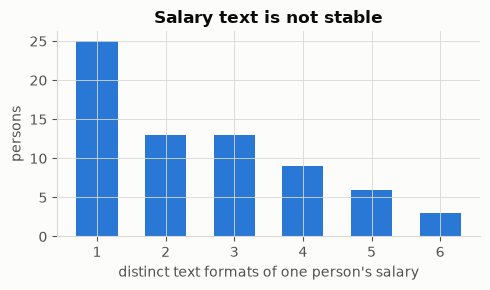

In [21]:
# Does one employer always use the same text? Number of distinct text formats per earner
formats = sal.groupby("person_id").text_key.nunique()
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(formats.value_counts().sort_index().index, formats.value_counts().sort_index().values,
       color=COLORS["blue"], width=0.6)
ax.set(xlabel="distinct text formats of one person's salary", ylabel="persons", title="Salary text is not stable")
save(fig, FIG / "eda_formats.png")

X[(X.person_id == "P041") & (X.amount > 2000)][["date", "amount", "text", "is_salary"]]

**Finding 6: the text is unreliable in both directions.**
- 36% of salaries don't say "lön": employer name only (21%), empty (10%), broken letters (1%),
  or truncated.
- 56 credits say "lön" but are not salary: Swish from friends, "överföring lön", and private
  transfers.
- The same employer's text changes from month to month. P041 alternates between "LÖN",
  "NORDIC DATA GROUP AB" and "Lön Nordic Data Group AB", and also gets two "LÖN" credits that
  are *not* salary (wrong day, wrong amount).

## 7. Other income: who has no salary?

CSN amounts: {13156.0: 72}
Earners who also get CSN: ['P040', 'P043']


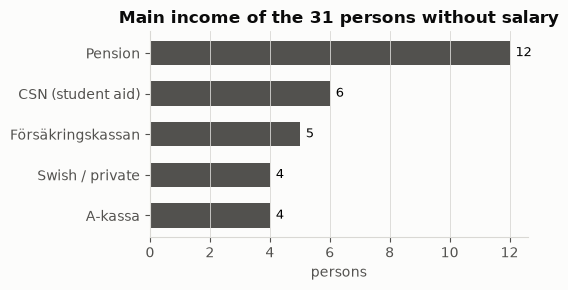

In [22]:
ext = X[X.income_type != "Own transfer"]
main_income = (ext.groupby(["person_id", "income_type"]).amount.sum().reset_index()
               .sort_values("amount").groupby("person_id").last().income_type)
no_salary = main_income.drop(earners.index)

fig, ax = plt.subplots(figsize=(5.5, 3))
vc = no_salary.value_counts()[::-1]
ax.barh(vc.index, vc.values, color=COLORS["muted"], height=0.6)
for i, v in enumerate(vc.values):
    ax.text(v + 0.2, i, str(v), va="center", fontsize=9)
ax.set(xlabel="persons", title=f"Main income of the {len(no_salary)} persons without salary")
ax.grid(axis="y", visible=False)
save(fig, FIG / "eda_no_salary.png")

print("CSN amounts:", X[X.income_type == "CSN (student aid)"].amount.value_counts().to_dict())
print("Earners who also get CSN:", sorted(set(earners.index) & set(X[X.kw_student_aid == 1].person_id)))

,count,mean,std,min,25%,50%,75%,max
salary share,69.0,0.94,0.13,0.26,0.93,0.97,0.99,1.0


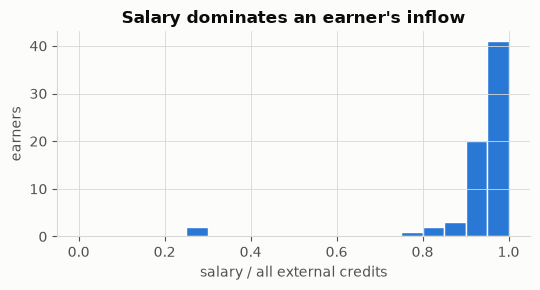

In [23]:
# How much of an earner's external inflow is salary?
inflow = ext.groupby("person_id").amount.sum()
share = (sal.groupby("person_id").amount.sum() / inflow[earners.index])
fig, ax = plt.subplots(figsize=(5.5, 3))
ax.hist(share, bins=np.linspace(0, 1, 21), color=COLORS["blue"], edgecolor="white")
ax.set(xlabel="salary / all external credits", ylabel="earners", title="Salary dominates an earner's inflow")
save(fig, FIG / "eda_salary_share.png")
share.describe().round(2).to_frame("salary share").T

**Finding 7:** the 31 persons without salary are mainly pensioners, students (CSN, always exactly
13,156 SEK), and people on Försäkringskassan or a-kassa. Their income is just as regular as a
salary. For earners, salary is typically **97%** of all external inflow.

## 8. Summary: what this means for the classifier

| Evidence | Separates salary from | Fails on |
|---|---|---|
| **Text** ("lön", employer name) | pension, CSN, benefits (they are named) | empty/broken text, "Swish lön" from friends |
| **Rhythm** (25th, monthly, stable amount, big share of inflow) | Swish, one-off "lön" transfers, refunds | CSN, a-kassa, Försäkringskassan (also monthly) |
| **Amount** | Swish, small payments | benefits and own transfers of similar size |

No single type of evidence is enough, and each covers the others' weak spots. The classifier
(notebook 02) therefore combines **text features and pattern features**, computed within each
person's own history.

We save the key numbers for the slides:

In [24]:
findings = {
    "transactions": len(txns),
    "debit_share": round(float((~txns.is_credit).mean()), 3),
    "credits": len(X),
    "salary_transactions": int(X.is_salary.sum()),
    "persons": int(txns.person_id.nunique()),
    "persons_with_salary": len(earners),
    "persons_two_accounts": int((persons.accounts == 2).sum()),
    "persons_start_after_jan": int((persons.start > "2025-01-31").sum()),
    "persons_end_before_dec": int((persons.end < "2025-12-01").sum()),
    "salary_share_on_payday25": round(float(sal.on_payday25.mean()), 3),
    "persons_paid_twice_a_month": int((earners.per_month > 1.5).sum()),
    "salary_median_monthly": round(float(earners.monthly_salary.median())),
    "text_formats_per_salary_person_max": int(formats.max()),
    "salary_text_evidence": evidence.salaries.to_dict(),
    "lon_keyword_not_salary": len(decoys),
    "lon_keyword_not_salary_persons": int(decoys.person_id.nunique()),
    "payday25_share_by_income_type": X.groupby("income_type").on_payday25.mean().round(2).to_dict(),
    "no_salary_person_main_income": no_salary.value_counts().to_dict(),
    "salary_share_of_inflow_median": round(float(share.median()), 2),
}
(REPORTS / "eda_findings.json").write_text(json.dumps(findings, indent=2, ensure_ascii=False))
findings

{'transactions': 30301,
 'debit_share': 0.931,
 'credits': 2093,
 'salary_transactions': 876,
 'persons': 100,
 'persons_with_salary': 69,
 'persons_two_accounts': 27,
 'persons_start_after_jan': 11,
 'persons_end_before_dec': 6,
 'salary_share_on_payday25': 0.788,
 'persons_paid_twice_a_month': 8,
 'salary_median_monthly': 31370,
 'text_formats_per_salary_person_max': 6,
 'salary_text_evidence': {'salary keyword': 558,
  'employer name': 181,
  'empty text': 84,
  'other text': 42,
  'corrupted text': 11},
 'lon_keyword_not_salary': 56,
 'lon_keyword_not_salary_persons': 33,
 'payday25_share_by_income_type': {'A-kassa': 0.61,
  'CSN (student aid)': 1.0,
  'Försäkringskassan': 0.66,
  'Own transfer': 0.02,
  'Pension': 0.0,
  'Salary': 0.79,
  'Swish / private': 0.04,
  'Tax refund / insurance': 0.0},
 'no_salary_person_main_income': {'Pension': 12,
  'CSN (student aid)': 6,
  'Försäkringskassan': 5,
  'Swish / private': 4,
  'A-kassa': 4},
 'salary_share_of_inflow_median': 0.97}